# ĐỒ ÁN GIỮA KỲ: THU THẬP VÀ PHÂN TÍCH DỮ LIỆU GIÁ VÀNG

## 1. Giới thiệu bài toán

Dự án này tập trung vào việc **Phân tích và khảo sát tính khả thi** cho mô hình dự báo giá Vàng. Đây là bài toán thuộc loại **Hồi quy (Regression)**, trong đó chúng ta cố gắng dự đoán biến mục tiêu ($Y$) dựa trên các đặc trưng ($X_i$) từ thị trường tài chính toàn cầu.

* **Biến mục tiêu ($Y$):** Giá đóng cửa của Vàng (`GC=F`).
* **Các đặc trưng ($X_i$):** Giá Bạc (`SI=F`), Chỉ số S&P 500 (`^GSPC`), Giá dầu thô (`CL=F`), và Chỉ số đồng USD (`DX-Y.NYB`),...

## 2. Quy trình thu thập dữ liệu (Data Crawling)

Dữ liệu được thu thập từ nguồn **Yahoo Finance** thông qua thư viện `yfinance`, đảm bảo tính cập nhật và chính xác cao.

* **Thời gian:** 01/01/2015 - 01/03/2026 (Đảm bảo > 1000 mẫu theo yêu cầu).
* **Phương pháp:** Sử dụng hàm `generalize_data()` để tự động hóa việc tải, kiểm tra cấu trúc và lưu trữ dữ liệu thô vào thư mục `raw_data/`.

## 3. Thống kê mô tả và Trực quan hóa sơ bộ

Trước khi đi vào tiền xử lý, mỗi loại dữ liệu sẽ được đánh giá qua:

* **Thống kê số học:** Xem xét các chỉ số `mean`, `std`, `min`, `max` thông qua hàm `.describe()`.
* **Biểu đồ xu hướng:** Sử dụng Line Chart và đường trung bình động (MA50) để nhận diện chu kỳ thị trường.
* **Biểu đồ biến động:** Sử dụng Histogram để quan sát phân phối của tỷ suất lợi nhuận hàng ngày (Daily Returns).

## 4. Tích hợp dữ liệu (Data Integration)

Sau khi thu thập đủ các nguồn, dữ liệu sẽ được hợp nhất (Merge) dựa trên cột thời gian (`Date`):

* Giữ lại toàn bộ thông tin (OHLCV) của dữ liệu **Vàng**.
* Chỉ trích xuất cột giá đóng cửa (**Close**) của các chỉ số phụ để làm đặc trưng dự báo.
* Tất cả sẽ được lưu vào tệp tổng hợp `gold_integrated.csv` để chuẩn bị cho bước **Data Cleaning** (Làm sạch dữ liệu) ở giai đoạn tiếp theo.

### <span style="color: white; font-weight: bold">Khai báo thư viện và đường dẫn thư mục</span>

In [27]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas_datareader.data as web
import datetime
import os

data_dir = "../raw_data"
data_dir_processed = "../processed_data"

### <span style="color: white; font-weight: bold">Khai báo hàm generalize_data() để scrawl và thống kê dữ liệu từ Yahoo Finance</span>

In [7]:
def generalize_data(ticker_symbol, file_name, start_date, end_date, interval):
    # 2. Tải dữ liệu
    # period: khoảng thời gian (1d, 5d, 1mo, 1y, 5y, max, etc.)
    # interval: tần suất dữ liệu (1m, 2m, 5m, 15m, 30m, 60m, 90m, 1h, 1d, 5d, 1wk, 1mo, 3mo)
    data = yf.download(ticker_symbol, start=start_date, end=end_date, interval=interval)

    # 3. Kiểm tra dữ liệu
    print("Dữ liệu 5 dòng đầu tiên:")
    print(data.head())

    # 4. Lưu dữ liệu ra file CSV để tiện phân tích sau này (không cần cào lại nhiều lần)
    data.to_csv(f"{data_dir}/{file_name}", index=True)

    print(f"\nĐã lưu dữ liệu vào file {file_name} thành công!")
    # --- THỐNG KÊ MÔ TẢ ---

    # 1. Thông tin tổng quát (kiểu dữ liệu, số lượng dòng non-null)
    print("--- Thông tin cấu trúc dữ liệu ---")
    print(data.info())

    # 2. Thống kê số liệu (Mean, Median, Std, Min, Max,...)
    print("\n--- Bảng thống kê mô tả chi tiết ---")
    # .describe() cung cấp cái nhìn nhanh về độ lệch và phân tán
    print(data.describe())

    # 3. Kiểm tra dữ liệu thiếu (Missing values)
    print("\n--- Kiểm tra giá trị thiếu ---")
    print(data.isnull().sum())
    

    return data

### <span style="color: Gold; font-weight: bold">Dữ liệu giá vàng</span>

In [6]:
ticker_symbol = "GC=F"

# Gọi hàm để lấy dữ liệu và thực hiện EDA
gold_data = generalize_data(ticker_symbol, "gold_data.csv", "2015-01-01", "2026-03-01", "1d")

[*********************100%***********************]  1 of 1 completed

Dữ liệu 5 dòng đầu tiên:
Price             Close         High          Low         Open Volume
Ticker             GC=F         GC=F         GC=F         GC=F   GC=F
Date                                                                 
2015-01-02  1186.000000  1194.500000  1169.500000  1184.000000    138
2015-01-05  1203.900024  1206.900024  1180.099976  1180.300049    470
2015-01-06  1219.300049  1220.000000  1203.500000  1203.500000     97
2015-01-07  1210.599976  1219.199951  1210.599976  1219.199951     29
2015-01-08  1208.400024  1215.699951  1206.300049  1207.000000     92

Đã lưu dữ liệu vào file gold_data.csv thành công!
--- Thông tin cấu trúc dữ liệu ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2804 entries, 2015-01-02 to 2026-02-27
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, GC=F)   2804 non-null   float64
 1   (High, GC=F)    2804 non-null   float64
 2   (Low, GC=F)     2804

In [7]:
gold_data['Daily_Return'] = gold_data['Close'].pct_change()
print(f"\nBiến động trung bình hàng ngày: {gold_data['Daily_Return'].mean():.4%}")


Biến động trung bình hàng ngày: 0.0581%


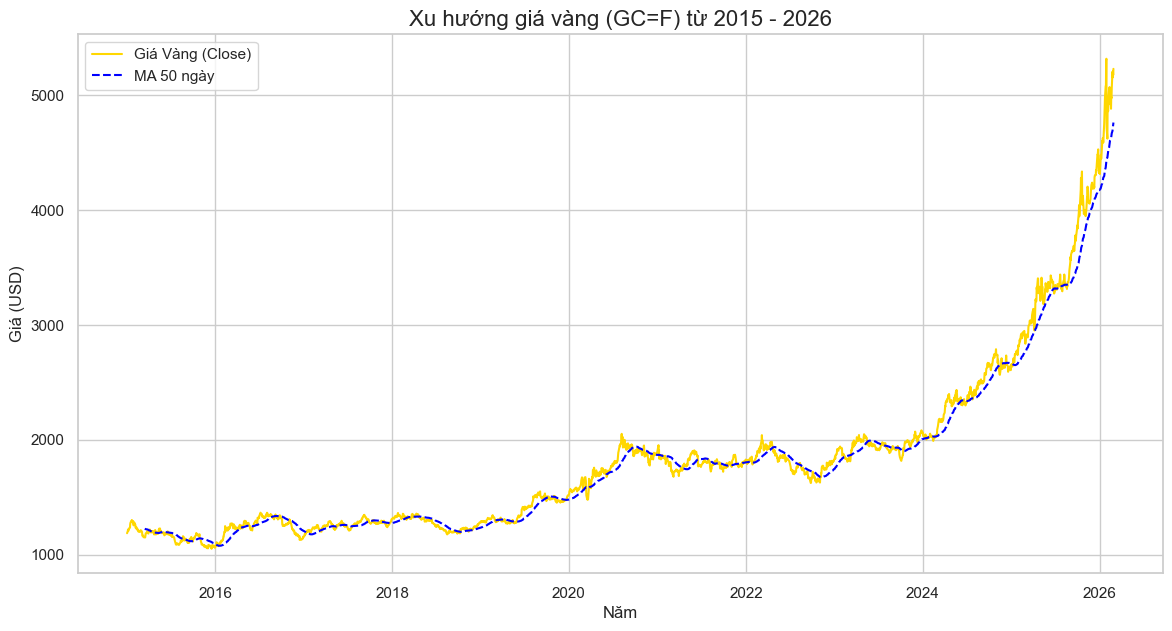

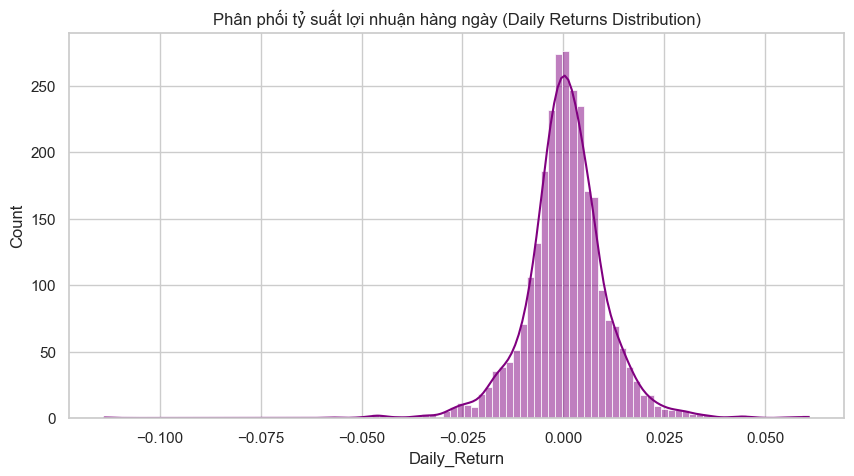

In [8]:
# Thiết lập giao diện biểu đồ
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))

# Vẽ biểu đồ giá đóng cửa (Close Price)
plt.plot(gold_data.index, gold_data['Close'], label='Giá Vàng (Close)', color='gold', linewidth=1.5)

# Thêm đường trung bình động (Moving Average) để thấy xu hướng dài hạn
gold_data['MA50'] = gold_data['Close'].rolling(window=50).mean()
plt.plot(gold_data.index, gold_data['MA50'], label='MA 50 ngày', color='blue', linestyle='--')

plt.title(f'Xu hướng giá vàng ({ticker_symbol}) từ 2015 - 2026', fontsize=16)
plt.xlabel('Năm')
plt.ylabel('Giá (USD)')
plt.legend()
plt.show()

# Vẽ biểu đồ phân phối biến động (Histogram of Returns)

plt.figure(figsize=(10, 5))
sns.histplot(gold_data['Daily_Return'].dropna(), bins=100, kde=True, color='purple')
plt.title('Phân phối tỷ suất lợi nhuận hàng ngày (Daily Returns Distribution)')
plt.show()

### <span style="color: silver; font-weight: bold">Dữ liệu giá bạc</span>

In [3]:
ticker_symbol = "SI=F"

silver_data = generalize_data(ticker_symbol, "silver_data.csv", "2015-01-01", "2026-03-01", "1d")

[*********************100%***********************]  1 of 1 completed

Dữ liệu 5 dòng đầu tiên:
Price           Close       High        Low       Open Volume
Ticker           SI=F       SI=F       SI=F       SI=F   SI=F
Date                                                         
2015-01-02  15.734000  15.815000  15.535000  15.790000     13
2015-01-05  16.179001  16.179001  16.179001  16.179001      0
2015-01-06  16.603001  16.603001  16.603001  16.603001      2
2015-01-07  16.510000  16.549999  16.480000  16.480000      9
2015-01-08  16.351000  16.351000  16.351000  16.351000      0

Đã lưu dữ liệu vào file silver_data.csv thành công!
--- Thông tin cấu trúc dữ liệu ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2804 entries, 2015-01-02 to 2026-02-27
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, SI=F)   2804 non-null   float64
 1   (High, SI=F)    2804 non-null   float64
 2   (Low, SI=F)     2804 non-null   float64
 3   (Open, SI=F)    2804 non-null   float

In [4]:
silver_data['Daily_Return'] = silver_data['Close'].pct_change()
print(f"\nBiến động trung bình hàng ngày: {silver_data['Daily_Return'].mean():.4%}")


Biến động trung bình hàng ngày: 0.0848%


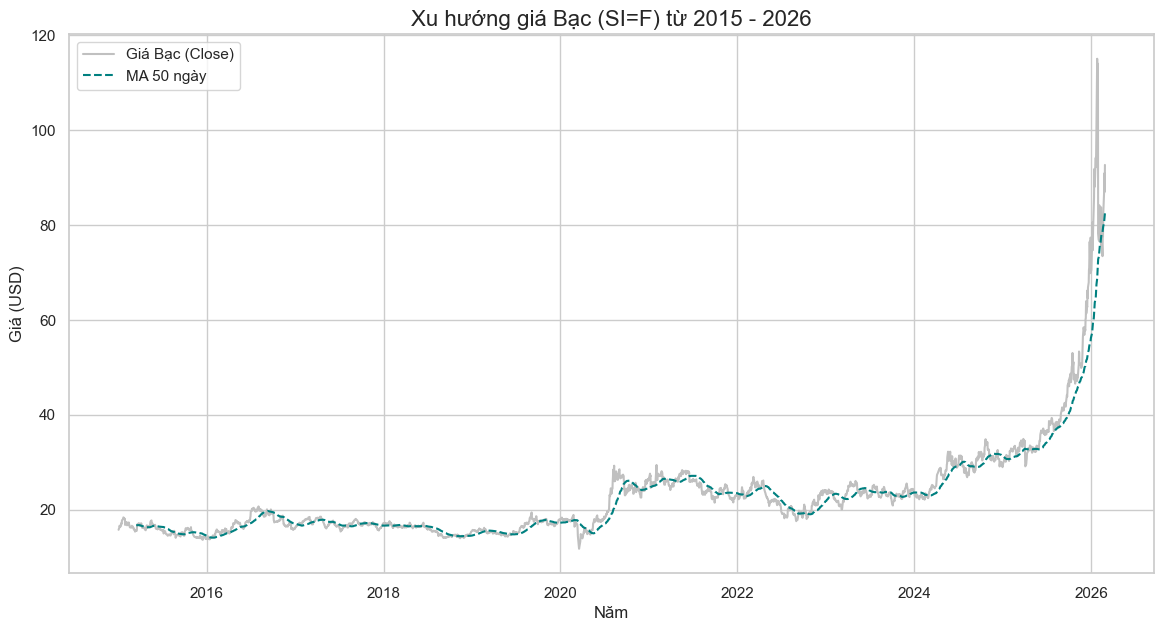

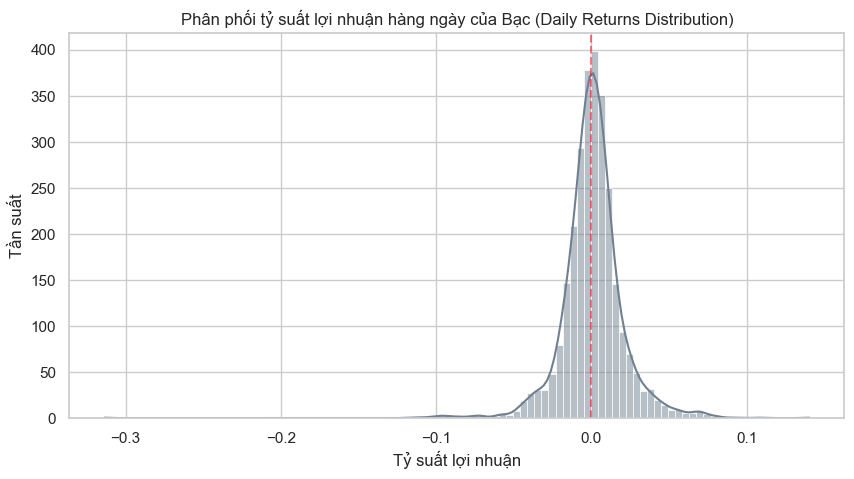

In [5]:
# --- TRỰC QUAN HÓA DỮ LIỆU BẠC (SILVER) ---

# Thiết lập giao diện biểu đồ
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))

# 1. Vẽ biểu đồ giá đóng cửa (Close Price) của Bạc
# Lưu ý: Đảm bảo silver_data đã được tải thành công
plt.plot(silver_data.index, silver_data['Close'], label='Giá Bạc (Close)', color='silver', linewidth=1.5)

# Thêm đường trung bình động (Moving Average) để thấy xu hướng dài hạn của Bạc
silver_data['MA50'] = silver_data['Close'].rolling(window=50).mean()
plt.plot(silver_data.index, silver_data['MA50'], label='MA 50 ngày', color='teal', linestyle='--')

plt.title(f'Xu hướng giá Bạc (SI=F) từ 2015 - 2026', fontsize=16)
plt.xlabel('Năm')
plt.ylabel('Giá (USD)')
plt.legend()
plt.show()

# 2. Vẽ biểu đồ phân phối biến động (Histogram of Returns) cho Bạc
# Tính Daily_Return nếu chưa có
if 'Daily_Return' not in silver_data.columns:
    silver_data['Daily_Return'] = silver_data['Close'].pct_change()

plt.figure(figsize=(10, 5))
sns.histplot(silver_data['Daily_Return'].dropna(), bins=100, kde=True, color='slategray')
plt.axvline(x=0, color='red', linestyle='--', alpha=0.5) # Đường mốc 0% để thấy mức tăng/giảm
plt.title('Phân phối tỷ suất lợi nhuận hàng ngày của Bạc (Daily Returns Distribution)')
plt.xlabel('Tỷ suất lợi nhuận')
plt.ylabel('Tần suất')
plt.show()

### <span style="color: royalblue; font-weight: bold">Dữ liệu chứng khoán S&P500</span>

In [6]:
ticker_symbol = "^GSPC"
sp500_data = generalize_data(ticker_symbol, "sp500_data.csv", "2015-01-01", "2026-03-01", "1d")

[*********************100%***********************]  1 of 1 completed

Dữ liệu 5 dòng đầu tiên:
Price             Close         High          Low         Open      Volume
Ticker            ^GSPC        ^GSPC        ^GSPC        ^GSPC       ^GSPC
Date                                                                      
2015-01-02  2058.199951  2072.360107  2046.040039  2058.899902  2708700000
2015-01-05  2020.579956  2054.439941  2017.339966  2054.439941  3799120000
2015-01-06  2002.609985  2030.250000  1992.439941  2022.150024  4460110000
2015-01-07  2025.900024  2029.609985  2005.550049  2005.550049  3805480000
2015-01-08  2062.139893  2064.080078  2030.609985  2030.609985  3934010000

Đã lưu dữ liệu vào file sp500_data.csv thành công!
--- Thông tin cấu trúc dữ liệu ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2805 entries, 2015-01-02 to 2026-02-27
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   (Close, ^GSPC)   2805 non-null   float64
 1   (High, ^GSPC)    2805

In [7]:
sp500_data['Daily_Return'] = sp500_data['Close'].pct_change()
print(f"\nBiến động trung bình hàng ngày: {sp500_data['Daily_Return'].mean():.4%}")


Biến động trung bình hàng ngày: 0.0494%


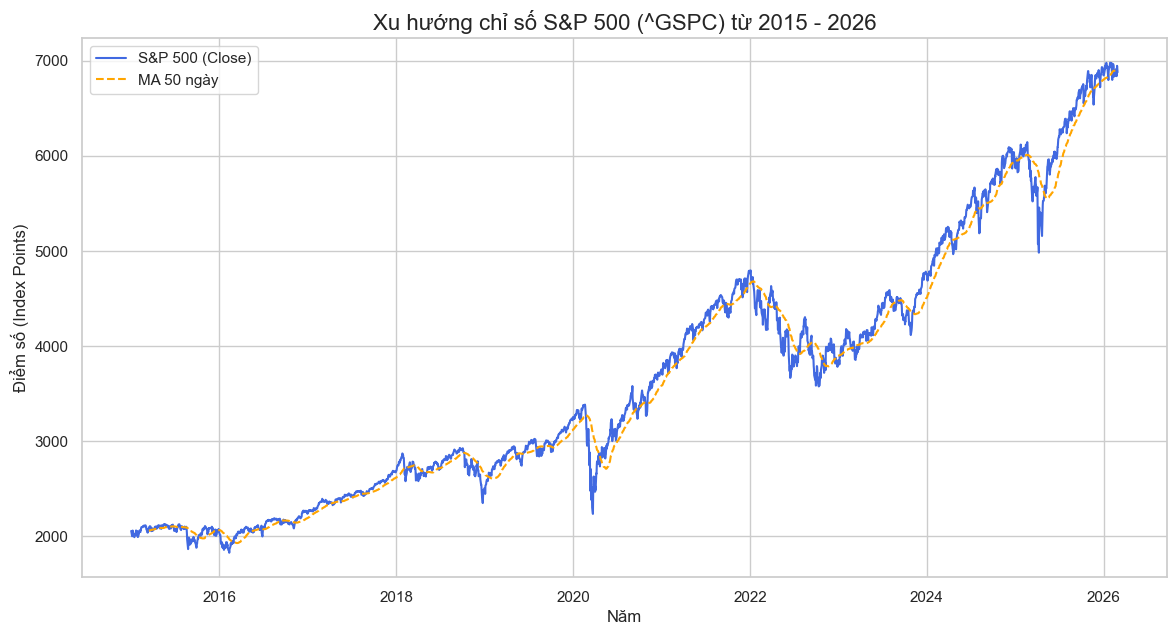

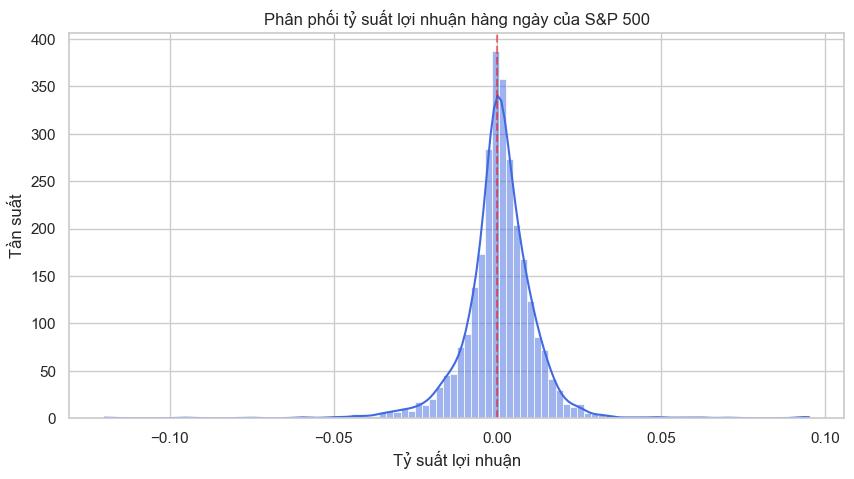

In [8]:
# --- TRỰC QUAN HÓA DỮ LIỆU S&P 500 (^GSPC) ---

# Thiết lập giao diện biểu đồ
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))

# 1. Vẽ biểu đồ giá đóng cửa (Close Price) của S&P 500
plt.plot(sp500_data.index, sp500_data['Close'], label='S&P 500 (Close)', color='royalblue', linewidth=1.5)

# Thêm đường trung bình động (Moving Average) để thấy xu hướng dài hạn
sp500_data['MA50'] = sp500_data['Close'].rolling(window=50).mean()
plt.plot(sp500_data.index, sp500_data['MA50'], label='MA 50 ngày', color='orange', linestyle='--')

plt.title(f'Xu hướng chỉ số S&P 500 ({ticker_symbol}) từ 2015 - 2026', fontsize=16)
plt.xlabel('Năm')
plt.ylabel('Điểm số (Index Points)')
plt.legend()
plt.show()

# 2. Vẽ biểu đồ phân phối biến động (Histogram of Returns) cho S&P 500
# Tính Daily_Return cho S&P 500
if 'Daily_Return' not in sp500_data.columns:
    sp500_data['Daily_Return'] = sp500_data['Close'].pct_change()

plt.figure(figsize=(10, 5))
sns.histplot(sp500_data['Daily_Return'].dropna(), bins=100, kde=True, color='royalblue')
plt.axvline(x=0, color='red', linestyle='--', alpha=0.5)
plt.title('Phân phối tỷ suất lợi nhuận hàng ngày của S&P 500')
plt.xlabel('Tỷ suất lợi nhuận')
plt.ylabel('Tần suất')
plt.show()

### <span style="color: forestgreen; font-weight: bold">Dữ liệu chỉ số đo lường sức mạnh đồng đô la Mỹ (USD) DXY</span>

In [9]:
ticker_symbol = "DX-Y.NYB"
dxy_data = generalize_data(ticker_symbol, "dxy_data.csv", "2015-01-01", "2026-03-01", "1d")

[*********************100%***********************]  1 of 1 completed

Dữ liệu 5 dòng đầu tiên:
Price           Close       High        Low       Open   Volume
Ticker       DX-Y.NYB   DX-Y.NYB   DX-Y.NYB   DX-Y.NYB DX-Y.NYB
Date                                                           
2015-01-02  91.080002  91.160004  90.330002  90.360001        0
2015-01-05  91.379997  91.779999  91.129997  91.129997        0
2015-01-06  91.500000  91.809998  91.120003  91.379997        0
2015-01-07  91.889999  92.269997  91.650002  91.750000        0
2015-01-08  92.370003  92.529999  91.940002  91.940002        0

Đã lưu dữ liệu vào file dxy_data.csv thành công!
--- Thông tin cấu trúc dữ liệu ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2806 entries, 2015-01-02 to 2026-02-27
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   (Close, DX-Y.NYB)   2806 non-null   float64
 1   (High, DX-Y.NYB)    2806 non-null   float64
 2   (Low, DX-Y.NYB)     2806 non-null   float64
 3   (Ope

In [10]:
dxy_data['Daily_Return'] = dxy_data['Close'].pct_change()
print(f"\nBiến động trung bình hàng ngày: {dxy_data['Daily_Return'].mean():.4%}")


Biến động trung bình hàng ngày: 0.0034%


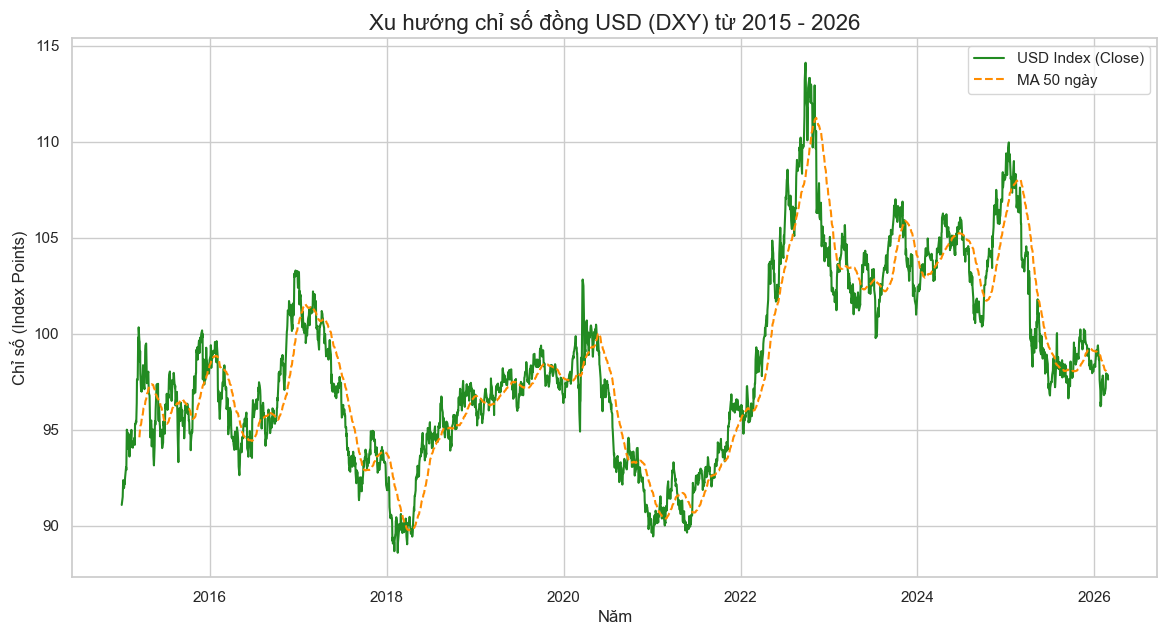

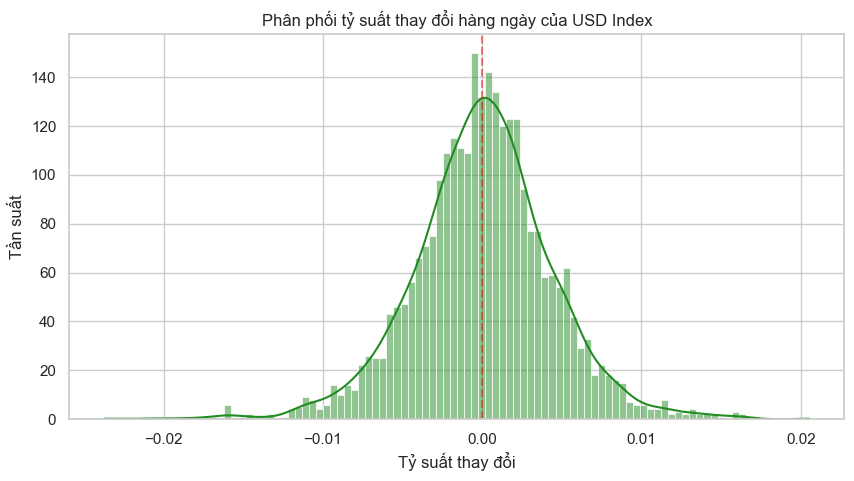

In [11]:
# --- TRỰC QUAN HÓA DỮ LIỆU CHỈ SỐ ĐỒNG USD (DX-Y.NYB) ---

# Thiết lập giao diện biểu đồ
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))

# 1. Vẽ biểu đồ giá đóng cửa (Close Price) của USD Index
# Giả sử dxy_data đã được crawl từ ticker "DX-Y.NYB"
plt.plot(dxy_data.index, dxy_data['Close'], label='USD Index (Close)', color='forestgreen', linewidth=1.5)

# Thêm đường trung bình động (MA50) để nhận diện xu hướng sức mạnh đồng USD
dxy_data['MA50'] = dxy_data['Close'].rolling(window=50).mean()
plt.plot(dxy_data.index, dxy_data['MA50'], label='MA 50 ngày', color='darkorange', linestyle='--')

plt.title('Xu hướng chỉ số đồng USD (DXY) từ 2015 - 2026', fontsize=16)
plt.xlabel('Năm')
plt.ylabel('Chỉ số (Index Points)')
plt.legend()
plt.show()

# 2. Vẽ biểu đồ phân phối biến động (Histogram of Returns) cho DXY
if 'Daily_Return' not in dxy_data.columns:
    dxy_data['Daily_Return'] = dxy_data['Close'].pct_change()

plt.figure(figsize=(10, 5))
sns.histplot(dxy_data['Daily_Return'].dropna(), bins=100, kde=True, color='forestgreen')
plt.axvline(x=0, color='red', linestyle='--', alpha=0.5)
plt.title('Phân phối tỷ suất thay đổi hàng ngày của USD Index')
plt.xlabel('Tỷ suất thay đổi')
plt.ylabel('Tần suất')
plt.show()

### <span style="color: teal; font-weight: bold">Dữ liệu lãi suất Mỹ 3 tháng (13 Week Treasury Build)</span>

In [3]:
ticker_symbol = "^IRX"
us3m_data = generalize_data(ticker_symbol, "us3m_data.csv", "2015-01-01", "2026-03-01", "1d")

[*********************100%***********************]  1 of 1 completed

Dữ liệu 5 dòng đầu tiên:
Price       Close   High    Low   Open Volume
Ticker       ^IRX   ^IRX   ^IRX   ^IRX   ^IRX
Date                                         
2015-01-02  0.015  0.030  0.015  0.030      0
2015-01-05  0.003  0.018  0.003  0.008      0
2015-01-06  0.020  0.023  0.018  0.023      0
2015-01-07  0.020  0.025  0.020  0.023      0
2015-01-08  0.018  0.020  0.015  0.020      0

Đã lưu dữ liệu vào file us3m_data.csv thành công!
--- Thông tin cấu trúc dữ liệu ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2804 entries, 2015-01-02 to 2026-02-27
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, ^IRX)   2804 non-null   float64
 1   (High, ^IRX)    2804 non-null   float64
 2   (Low, ^IRX)     2804 non-null   float64
 3   (Open, ^IRX)    2804 non-null   float64
 4   (Volume, ^IRX)  2804 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 131.4 KB
None

--- Bảng thống kê mô tả 

In [4]:
us3m_data['Daily_Return'] = us3m_data['Close'].pct_change()
print(f"\nBiến động trung bình hàng ngày: {us3m_data['Daily_Return'].mean():.4%}")


Biến động trung bình hàng ngày: 2.4721%


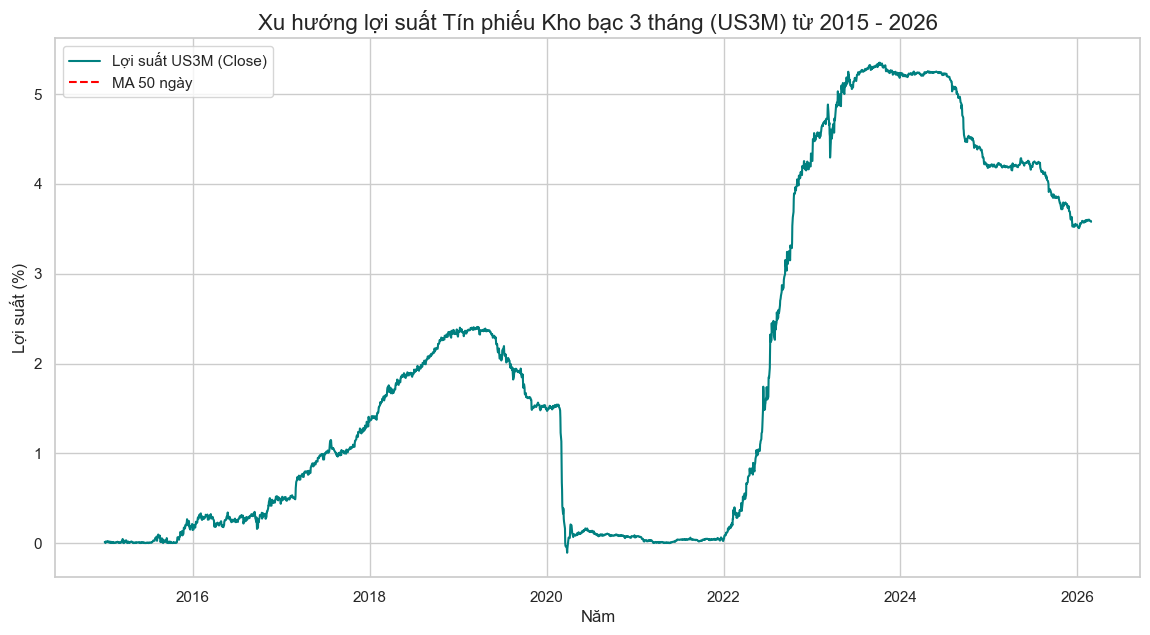

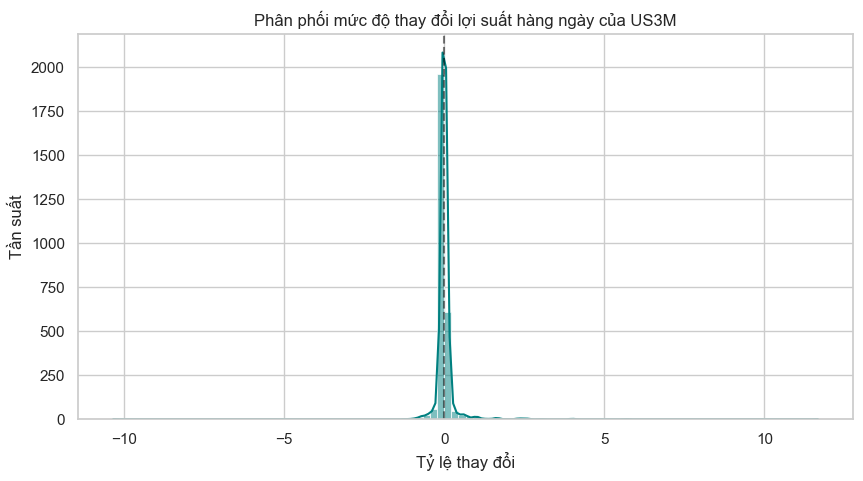

In [8]:
# --- TRỰC QUAN HÓA DỮ LIỆU TÍN PHIẾU KHO BẠC 3 THÁNG (US3M - ^IRX) ---

# Thiết lập giao diện biểu đồ
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))

# 1. Vẽ biểu đồ Lợi suất đóng cửa (Close Yield) của US3M
# Lưu ý: ^IRX trả về giá trị là tỷ lệ phần trăm (ví dụ 4.5 thay vì 0.045)
plt.plot(us3m_data.index, us3m_data['Close'], label='Lợi suất US3M (Close)', color='teal', linewidth=1.5)

# Thêm đường trung bình động (MA50) để thấy xu hướng lãi suất ngắn hạn
us3m_data['MA50'] = us3m_data['Close'].rolling(window=50).mean()
plt.plot(us3m_data.index, us3m_data['MA50'], label='MA 50 ngày', color='red', linestyle='--')

plt.title('Xu hướng lợi suất Tín phiếu Kho bạc 3 tháng (US3M) từ 2015 - 2026', fontsize=16)
plt.xlabel('Năm')
plt.ylabel('Lợi suất (%)')
plt.legend()
plt.show()

# 2. Vẽ biểu đồ phân phối biến động (Histogram of Returns) cho US3M
# Tính Daily_Return (Biến động lợi suất hàng ngày)
if 'Daily_Return' not in us3m_data.columns:
    us3m_data['Daily_Return'] = us3m_data['Close'].pct_change()

plt.figure(figsize=(10, 5))
# Loại bỏ giá trị vô cùng (inf) nếu có do lãi suất bằng 0 ở một số thời điểm
clean_returns = us3m_data['Daily_Return'].replace([np.inf, -np.inf], np.nan).dropna()

sns.histplot(clean_returns, bins=100, kde=True, color='teal')
plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
plt.title('Phân phối mức độ thay đổi lợi suất hàng ngày của US3M')
plt.xlabel('Tỷ lệ thay đổi')
plt.ylabel('Tần suất')
plt.show()

### <span style="color: purple; font-weight: bold">Chỉ số sợ hãi VIX</span>

In [9]:
ticker_symbol = "^VIX"
vix_data = generalize_data(ticker_symbol, "vix_data.csv", "2015-01-01", "2026-03-01", "1d")

[*********************100%***********************]  1 of 1 completed

Dữ liệu 5 dòng đầu tiên:
Price           Close       High        Low       Open Volume
Ticker           ^VIX       ^VIX       ^VIX       ^VIX   ^VIX
Date                                                         
2015-01-02  17.790001  20.139999  17.049999  17.760000      0
2015-01-05  19.920000  21.290001  19.190001  19.190001      0
2015-01-06  21.120001  22.900000  19.520000  20.330000      0
2015-01-07  19.309999  20.719999  19.040001  20.150000      0
2015-01-08  17.010000  18.090000  16.990000  17.930000      0

Đã lưu dữ liệu vào file vix_data.csv thành công!
--- Thông tin cấu trúc dữ liệu ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2805 entries, 2015-01-02 to 2026-02-27
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, ^VIX)   2805 non-null   float64
 1   (High, ^VIX)    2805 non-null   float64
 2   (Low, ^VIX)     2805 non-null   float64
 3   (Open, ^VIX)    2805 non-null   float64


In [10]:
vix_data['Daily_Return'] = vix_data['Close'].pct_change()
print(f"\nBiến động trung bình hàng ngày: {vix_data['Daily_Return'].mean():.4%}")


Biến động trung bình hàng ngày: 0.3415%


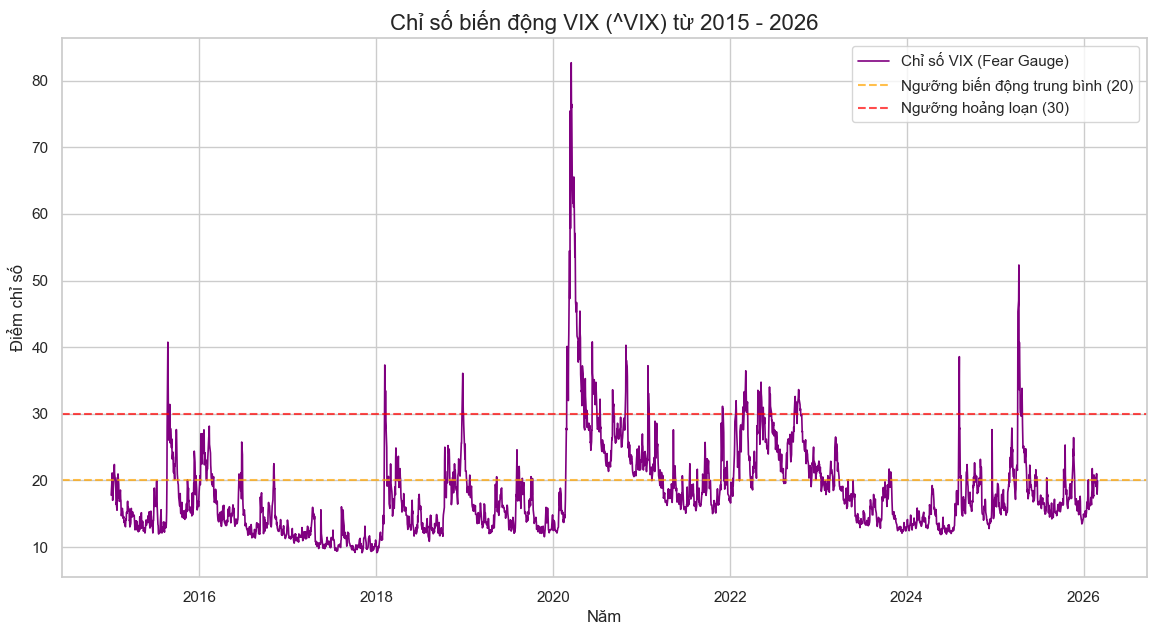

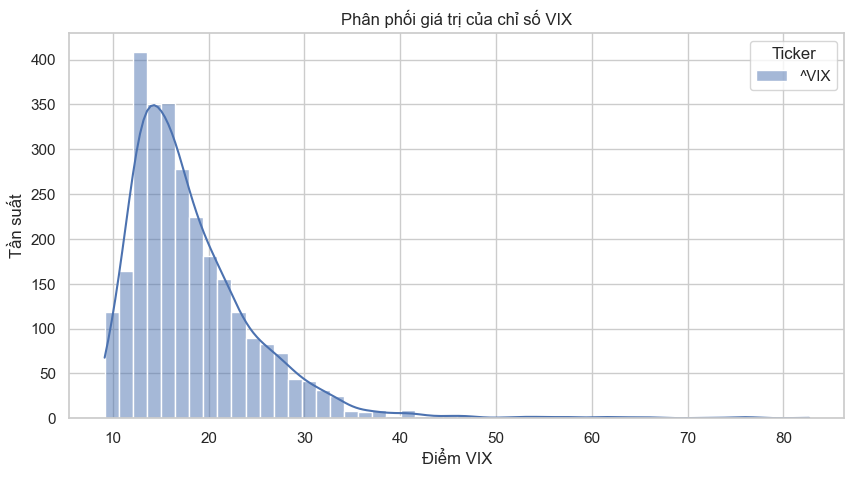

Thống kê mô tả VIX:
Ticker         ^VIX
count   2805.000000
mean      18.321173
std        7.084517
min        9.140000
25%       13.600000
50%       16.540001
75%       21.150000
max       82.690002


In [11]:
# --- TRỰC QUAN HÓA CHỈ SỐ BIẾN ĐỘNG CBOE (VIX - ^VIX) ---

# Thiết lập giao diện biểu đồ
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))

# 1. Vẽ biểu đồ chỉ số VIX
# VIX không phải là giá tiền mà là điểm số biến động (%)
plt.plot(vix_data.index, vix_data['Close'], label='Chỉ số VIX (Fear Gauge)', color='purple', linewidth=1.2)

# Thêm các đường ngưỡng tâm lý quan trọng
plt.axhline(y=20, color='orange', linestyle='--', alpha=0.7, label='Ngưỡng biến động trung bình (20)')
plt.axhline(y=30, color='red', linestyle='--', alpha=0.7, label='Ngưỡng hoảng loạn (30)')

plt.title('Chỉ số biến động VIX (^VIX) từ 2015 - 2026', fontsize=16)
plt.xlabel('Năm')
plt.ylabel('Điểm chỉ số')
plt.legend()
plt.show()

# 2. Vẽ biểu đồ phân phối giá trị VIX (Histogram)
# Đối với VIX, chúng ta thường quan tâm đến giá trị tuyệt đối hơn là % thay đổi
plt.figure(figsize=(10, 5))
sns.histplot(vix_data['Close'], bins=50, kde=True, color='purple')

plt.title('Phân phối giá trị của chỉ số VIX')
plt.xlabel('Điểm VIX')
plt.ylabel('Tần suất')
plt.show()

# Thống kê mô tả nhanh cho VIX
print("Thống kê mô tả VIX:")
print(vix_data['Close'].describe())

### <span style="color: lightblack; font-weight: bold">Dữ liệu giá dầu thô</span>

In [12]:
ticker_symbol = "CL=F"
oil_data = generalize_data(ticker_symbol, "oil_data.csv", "2015-01-01", "2026-03-01", "1d")

[*********************100%***********************]  1 of 1 completed

Dữ liệu 5 dòng đầu tiên:
Price           Close       High        Low       Open  Volume
Ticker           CL=F       CL=F       CL=F       CL=F    CL=F
Date                                                          
2015-01-02  52.689999  55.110001  52.029999  53.759998  268708
2015-01-05  50.040001  52.730000  49.680000  52.610001  375782
2015-01-06  47.930000  50.369999  47.549999  50.000000  451642
2015-01-07  48.650002  49.310001  46.830002  48.000000  460083
2015-01-08  48.790001  49.650002  47.730000  48.779999  362081

Đã lưu dữ liệu vào file oil_data.csv thành công!
--- Thông tin cấu trúc dữ liệu ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2805 entries, 2015-01-02 to 2026-02-27
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, CL=F)   2805 non-null   float64
 1   (High, CL=F)    2805 non-null   float64
 2   (Low, CL=F)     2805 non-null   float64
 3   (Open, CL=F)    2805 non-null   

In [13]:
oil_data['Daily_Return'] = oil_data['Close'].pct_change()
print(f"\nBiến động trung bình hàng ngày: {oil_data['Daily_Return'].mean():.4%}")


Biến động trung bình hàng ngày: -0.0838%


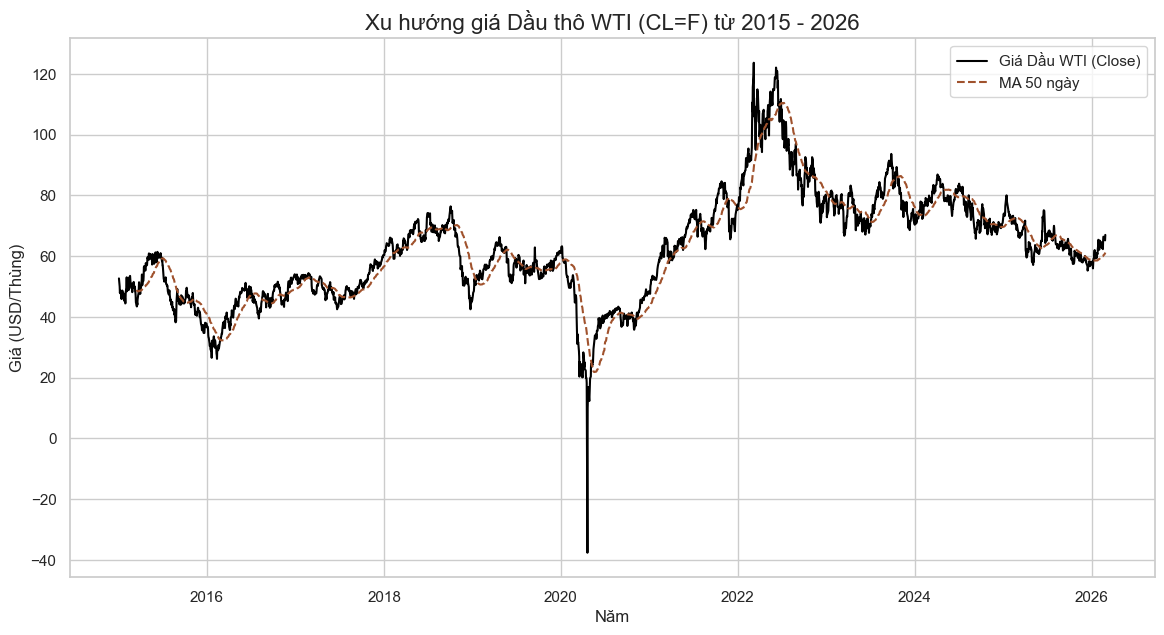

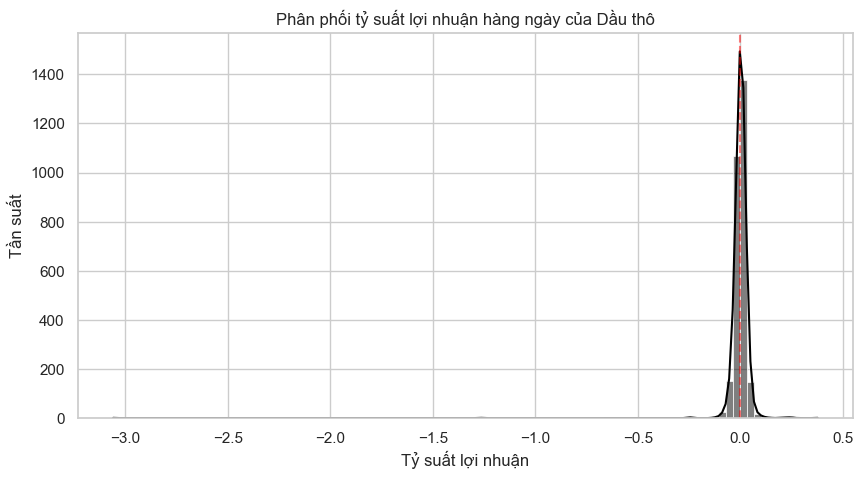

In [14]:
# --- TRỰC QUAN HÓA DỮ LIỆU GIÁ DẦU THÔ (CL=F) ---

# Thiết lập giao diện biểu đồ
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))

# 1. Vẽ biểu đồ giá đóng cửa (Close Price) của Dầu thô
plt.plot(oil_data.index, oil_data['Close'], label='Giá Dầu WTI (Close)', color='black', linewidth=1.5)

# Thêm đường trung bình động (MA50) để nhận diện xu hướng
oil_data['MA50'] = oil_data['Close'].rolling(window=50).mean()
plt.plot(oil_data.index, oil_data['MA50'], label='MA 50 ngày', color='sienna', linestyle='--')

plt.title('Xu hướng giá Dầu thô WTI (CL=F) từ 2015 - 2026', fontsize=16)
plt.xlabel('Năm')
plt.ylabel('Giá (USD/Thùng)')
plt.legend()
plt.show()

# 2. Vẽ biểu đồ phân phối biến động (Histogram of Returns) cho Dầu thô
if 'Daily_Return' not in oil_data.columns:
    oil_data['Daily_Return'] = oil_data['Close'].pct_change()

plt.figure(figsize=(10, 5))
sns.histplot(oil_data['Daily_Return'].dropna(), bins=100, kde=True, color='black')
plt.axvline(x=0, color='red', linestyle='--', alpha=0.5)
plt.title('Phân phối tỷ suất lợi nhuận hàng ngày của Dầu thô')
plt.xlabel('Tỷ suất lợi nhuận')
plt.ylabel('Tần suất')
plt.show()

### <span style="color: firebrick; font-weight: bold">Dữ liệu lãi suất thực trái phiếu kho bạc Mỹ kì hạn 10 năm DFII10</span>

In [19]:
# 1. Thiết lập thời gian
start = datetime.datetime(2015, 1, 1)
end = datetime.datetime(2026, 3, 1)

# 2. Cào dữ liệu DFII10 từ FRED
dfii10_data = web.DataReader("DFII10", "fred", start, end)

# 3. Xử lý giá trị thiếu (NaN)
# Dùng ffill() để điền giá trị của ngày gần nhất trước đó vào ô trống
# Sau đó dùng bfill() để xử lý trường hợp nếu những dòng đầu tiên bị trống
dfii10_data = dfii10_data.ffill().bfill()

# 4. Kiểm tra lại dữ liệu sau khi fill
print("Số lượng giá trị NaN sau khi xử lý:", dfii10_data.isnull().sum().sum())
print("\n5 dòng đầu tiên của DFII10:")
print(dfii10_data.head())

# 5. Lưu vào thư mục raw_data
dfii10_data.to_csv(f"{data_dir}/dfii10_data.csv")

Số lượng giá trị NaN sau khi xử lý: 0

5 dòng đầu tiên của DFII10:
            DFII10
DATE              
2015-01-01    0.41
2015-01-02    0.41
2015-01-05    0.40
2015-01-06    0.41
2015-01-07    0.39


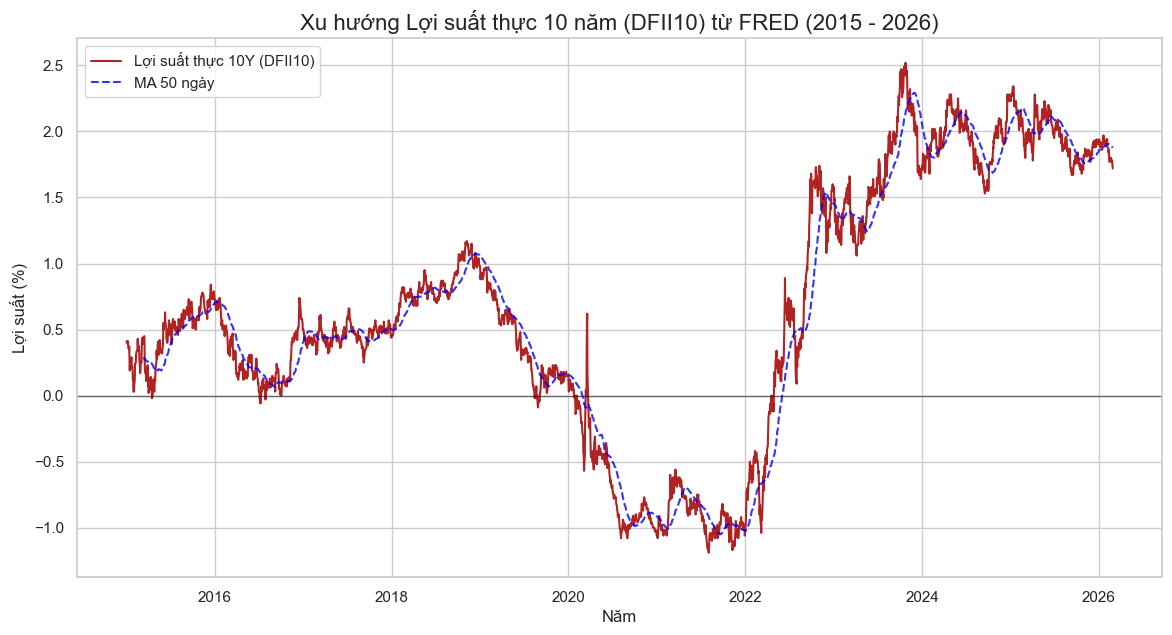

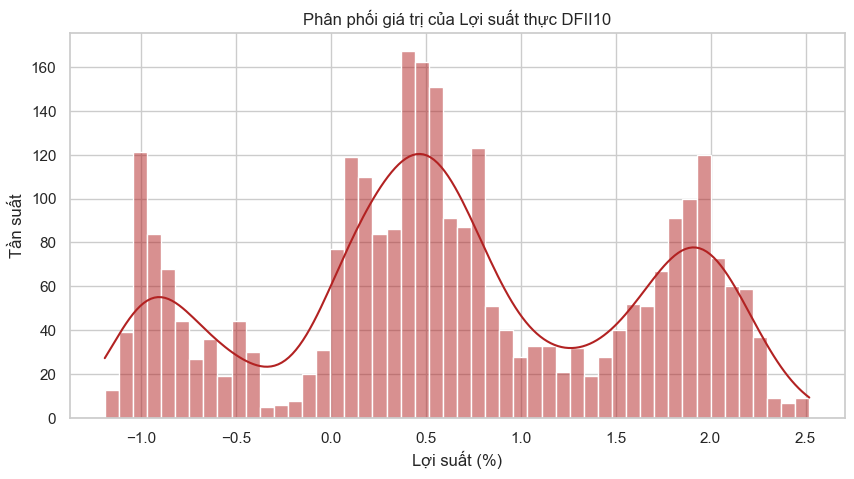

Thống kê mô tả DFII10:
count    2912.000000
mean        0.646707
std         0.960814
min        -1.190000
25%         0.110000
50%         0.540000
75%         1.560000
max         2.520000
Name: DFII10, dtype: float64


In [21]:
# --- TRỰC QUAN HÓA LỢI SUẤT THỰC 10 NĂM (DFII10) ---

# Thiết lập giao diện biểu đồ
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))

# 1. Vẽ biểu đồ Lợi suất thực (Real Yield)
# Lưu ý: Dữ liệu FRED trả về cột có tên là 'DFII10'
plt.plot(dfii10_data.index, dfii10_data['DFII10'], label='Lợi suất thực 10Y (DFII10)', color='firebrick', linewidth=1.5)

# Thêm đường mốc 0% - Ngưỡng cực kỳ quan trọng đối với giá Vàng
# Khi lợi suất thực âm, Vàng thường tăng rất mạnh
plt.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)

# Thêm đường trung bình động (MA50) để thấy xu hướng
dfii10_data['MA50'] = dfii10_data['DFII10'].rolling(window=50).mean()
plt.plot(dfii10_data.index, dfii10_data['MA50'], label='MA 50 ngày', color='blue', linestyle='--', alpha=0.8)

plt.title('Xu hướng Lợi suất thực 10 năm (DFII10) từ FRED (2015 - 2026)', fontsize=16)
plt.xlabel('Năm')
plt.ylabel('Lợi suất (%)')
plt.legend()
plt.show()

# 2. Vẽ biểu đồ phân phối giá trị (Histogram)
plt.figure(figsize=(10, 5))
sns.histplot(dfii10_data['DFII10'].dropna(), bins=50, kde=True, color='firebrick')

plt.title('Phân phối giá trị của Lợi suất thực DFII10')
plt.xlabel('Lợi suất (%)')
plt.ylabel('Tần suất')
plt.show()

# Thống kê mô tả nhanh
print("Thống kê mô tả DFII10:")
print(dfii10_data['DFII10'].describe())

### <span style="color: coral; font-weight: bold">Dữ liệu kỳ vọng lạm phát 10 năm T10YIE</span>

In [23]:
# Cào dữ liệu Kỳ vọng lạm phát 10 năm từ FRED
t10yie_data = web.DataReader("T10YIE", "fred", start, end)

# Xử lý NaN tương tự DFII10
t10yie_data = t10yie_data.ffill().bfill()

#Hiển thị thông tin sau khi xử lý
print("Số lượng giá trị NaN sau khi xử lý:", t10yie_data.isnull().sum().sum())
print("\n5 dòng đầu tiên của T10YIE:")
print(t10yie_data.head())

# Lưu vào raw_data
t10yie_data.to_csv(f"{data_dir}/t10yie_data.csv")

Số lượng giá trị NaN sau khi xử lý: 0

5 dòng đầu tiên của T10YIE:
            T10YIE
DATE              
2015-01-01    1.71
2015-01-02    1.71
2015-01-05    1.64
2015-01-06    1.56
2015-01-07    1.57


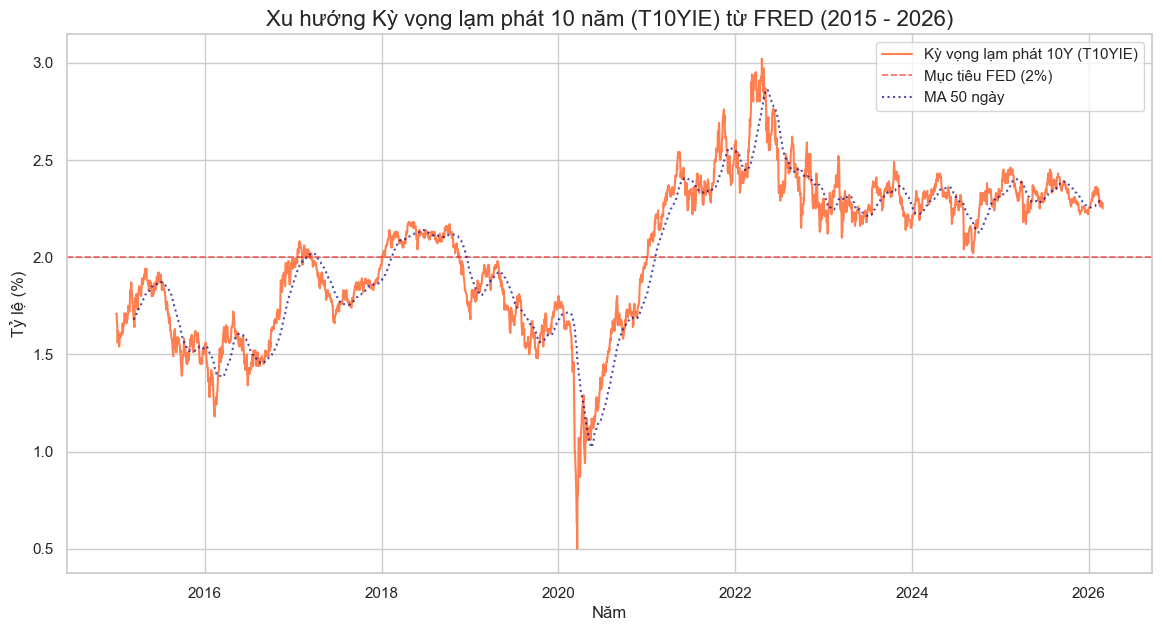

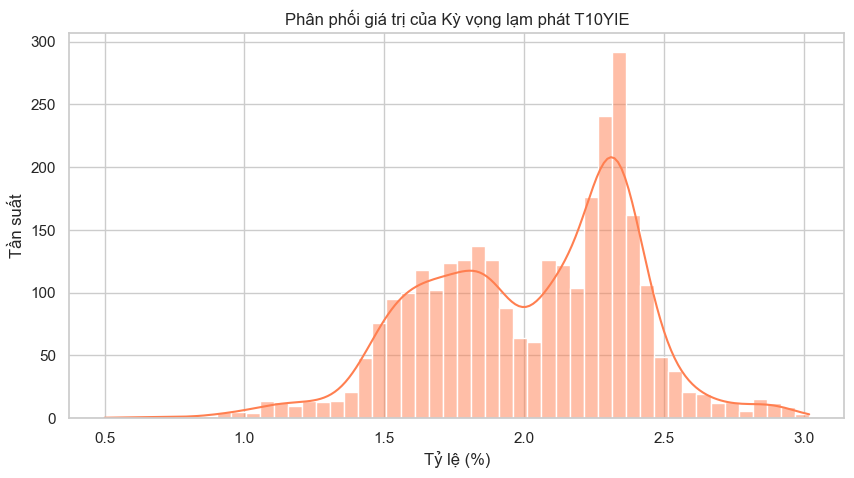

Thống kê mô tả T10YIE:
count    2912.000000
mean        2.022284
std         0.374477
min         0.500000
25%         1.730000
50%         2.090000
75%         2.320000
max         3.020000
Name: T10YIE, dtype: float64


In [24]:
# --- TRỰC QUAN HÓA KỲ VỌNG LẠM PHÁT 10 NĂM (T10YIE) ---

# Thiết lập giao diện biểu đồ
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))

# 1. Vẽ biểu đồ Kỳ vọng lạm phát (Breakeven Inflation Rate)
# Lưu ý: Dữ liệu FRED trả về cột có tên là 'T10YIE'
plt.plot(t10yie_data.index, t10yie_data['T10YIE'], label='Kỳ vọng lạm phát 10Y (T10YIE)', color='coral', linewidth=1.5)

# Thêm đường mốc 2% - Đây là mục tiêu lạm phát dài hạn của FED
plt.axhline(y=2, color='red', linestyle='--', linewidth=1.2, alpha=0.6, label='Mục tiêu FED (2%)')

# Thêm đường trung bình động (MA50) để thấy xu hướng thay đổi kỳ vọng
t10yie_data['MA50'] = t10yie_data['T10YIE'].rolling(window=50).mean()
plt.plot(t10yie_data.index, t10yie_data['MA50'], label='MA 50 ngày', color='darkblue', linestyle=':', alpha=0.7)

plt.title('Xu hướng Kỳ vọng lạm phát 10 năm (T10YIE) từ FRED (2015 - 2026)', fontsize=16)
plt.xlabel('Năm')
plt.ylabel('Tỷ lệ (%)')
plt.legend()
plt.show()

# 2. Vẽ biểu đồ phân phối giá trị (Histogram)
plt.figure(figsize=(10, 5))
sns.histplot(t10yie_data['T10YIE'].dropna(), bins=50, kde=True, color='coral')

plt.title('Phân phối giá trị của Kỳ vọng lạm phát T10YIE')
plt.xlabel('Tỷ lệ (%)')
plt.ylabel('Tần suất')
plt.show()

# Thống kê mô tả nhanh
print("Thống kê mô tả T10YIE:")
print(t10yie_data['T10YIE'].describe())

### <span style="color: steelblue; font-weight: bold">Dữ liệu chỉ số bất ổn chính sách kinh tế Mỹ USEPUINDXD</span>

In [25]:
# Cào dữ liệu Chỉ số bất ổn chính sách kinh tế (USEPUINDXD) từ FRED
usepu_data = web.DataReader("USEPUINDXD", "fred", start, end)

# Xử lý NaN (Chỉ số này cập nhật hàng ngày, nhưng vẫn nên fill cho chắc chắn)
usepu_data = usepu_data.ffill().bfill()

# Hiển thị thông tin sau khi xử lý
print("Số lượng giá trị NaN sau khi xử lý:", usepu_data.isnull().sum().sum())
print("\n5 dòng đầu tiên của USEPUINDXD:")
print(usepu_data.head())

# Lưu vào raw_data
usepu_data.to_csv(f"{data_dir}/usepu_data.csv")

Số lượng giá trị NaN sau khi xử lý: 0

5 dòng đầu tiên của USEPUINDXD:
            USEPUINDXD
DATE                  
2015-01-01      137.22
2015-01-02       93.14
2015-01-03       79.59
2015-01-04      163.12
2015-01-05       90.66


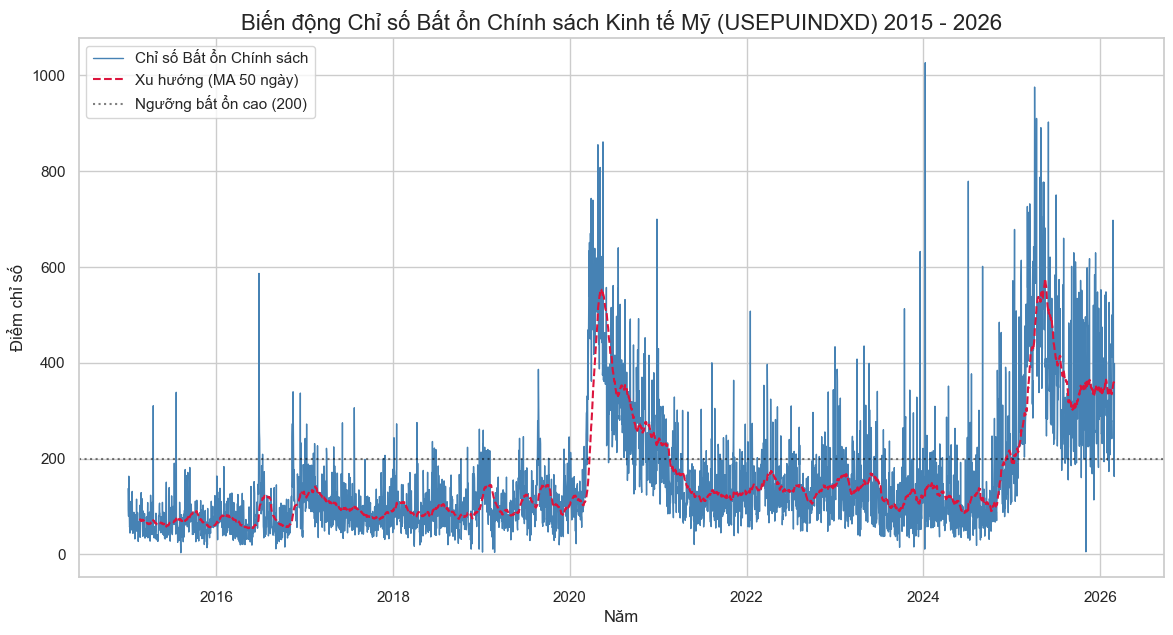

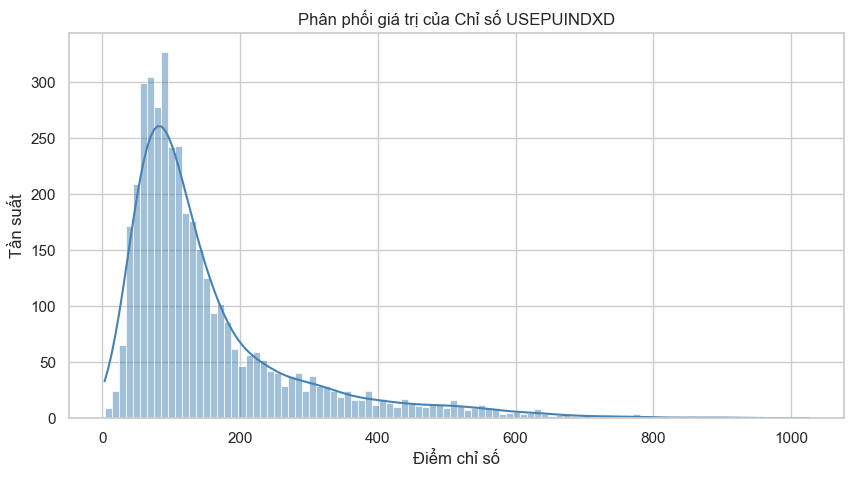

Thống kê mô tả USEPUINDXD:
count    4078.000000
mean      155.670927
std       131.561670
min         3.320000
25%        72.770000
50%       110.050000
75%       184.530000
max      1026.380000
Name: USEPUINDXD, dtype: float64


In [26]:
# --- TRỰC QUAN HÓA CHỈ SỐ BẤT ỔN CHÍNH SÁCH KINH TẾ (USEPUINDXD) ---

# Thiết lập giao diện biểu đồ
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))

# 1. Vẽ biểu đồ Chỉ số Bất ổn (Economic Policy Uncertainty)
# Dữ liệu FRED trả về cột có tên là 'USEPUINDXD'
plt.plot(usepu_data.index, usepu_data['USEPUINDXD'], label='Chỉ số Bất ổn Chính sách', color='steelblue', linewidth=1)

# Thêm đường trung bình động (MA50) để làm mượt các biến động nhiễu (noise)
usepu_data['MA50'] = usepu_data['USEPUINDXD'].rolling(window=50).mean()
plt.plot(usepu_data.index, usepu_data['MA50'], label='Xu hướng (MA 50 ngày)', color='crimson', linestyle='--')

# Đánh dấu các mốc quan trọng (Ví dụ: Ngưỡng 200 thường là mức bất ổn cao)
plt.axhline(y=200, color='black', linestyle=':', alpha=0.5, label='Ngưỡng bất ổn cao (200)')

plt.title('Biến động Chỉ số Bất ổn Chính sách Kinh tế Mỹ (USEPUINDXD) 2015 - 2026', fontsize=16)
plt.xlabel('Năm')
plt.ylabel('Điểm chỉ số')
plt.legend()
plt.show()

# 2. Vẽ biểu đồ phân phối giá trị (Histogram)
plt.figure(figsize=(10, 5))
sns.histplot(usepu_data['USEPUINDXD'].dropna(), bins=100, kde=True, color='steelblue')

plt.title('Phân phối giá trị của Chỉ số USEPUINDXD')
plt.xlabel('Điểm chỉ số')
plt.ylabel('Tần suất')
plt.show()

# Thống kê mô tả nhanh
print("Thống kê mô tả USEPUINDXD:")
print(usepu_data['USEPUINDXD'].describe())

In [32]:
           
output_dir = data_dir_processed
os.makedirs(output_dir, exist_ok=True)

# 2. Hàm đọc dữ liệu an toàn để xử lý lỗi header của yfinance
def read_finance_data(file_path):
    # Đọc tiêu đề để kiểm tra cấu trúc
    df_raw = pd.read_csv(file_path, nrows=5)
    
    # Nếu file có cấu trúc 3 dòng tiêu đề (Price, Ticker, Date) như yfinance thường xuất
    # Chúng ta bỏ qua dòng 2 (Ticker) và dòng 3 (Date rỗng)
    df = pd.read_csv(file_path, header=0, skiprows=[1, 2])
    
    # Đổi tên cột đầu tiên (thường là Price hoặc Ticker) thành 'Date'
    df.rename(columns={df.columns[0]: 'Date'}, inplace=True)
    
    # Chuyển đổi Date sang datetime
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)
    return df

# 3. Đọc file Vàng làm gốc (Base)
gold_path = os.path.join(data_dir, "gold_data.csv")
if os.path.exists(gold_path):
    # Giữ nguyên tất cả các cột của gold_data (Open, High, Low, Close, Volume...)
    final_df = read_finance_data(gold_path)
    
    # Gắn tiền tố 'gold_' để phân biệt với các chỉ số khác
    # final_df.columns = [f"gold_{col.lower()}" for col in final_df.columns]
    print(f"✅ Đã khởi tạo bảng từ gold_data.csv. Các cột: {list(final_df.columns)}")
else:
    raise FileNotFoundError("Không tìm thấy file gold_data.csv trong thư mục data_dir!")

# 4. Danh sách các file dataset khác cần merge thêm vào (chỉ lấy cột Close)
other_datasets = [
    ("silver_data.csv", "silver"),
    ("sp500_data.csv", "sp500"),
    ("dxy_data.csv", "dxy"),
    ("oil_data.csv", "oil"),
    ("vix_data.csv", "vix"),
    ("us3m_data.csv", "us3m"),
    ("dfii10_data.csv", "dfii10"),
    ("t10yie_data.csv", "t10yie"),
    ("usepu_data.csv", "usepuindxd")
]

# 5. Thực hiện Merge
for file_name, new_col_name in other_datasets:
    file_path = os.path.join(data_dir, file_name)
    
    if os.path.exists(file_path):
        try:
            df_extra = read_finance_data(file_path)
            
            # Lấy cột giá đóng cửa (thường là 'Close' hoặc cột đầu tiên nếu từ FRED)
            target_col = 'Close' if 'Close' in df_extra.columns else df_extra.columns[0]
            
            # Chỉ lấy 1 cột giá và đổi tên
            df_temp = df_extra[[target_col]].rename(columns={target_col: new_col_name})
            
            # Gộp vào bảng chính
            final_df = final_df.merge(df_temp, left_index=True, right_index=True, how='left')
            print(f"--- Đã thêm cột: {new_col_name} ---")
        except Exception as e:
            print(f"⚠️ Lỗi khi xử lý {file_name}: {e}")
    else:
        print(f"⚠️ Cảnh báo: Không tìm thấy file {file_name}")

# 6. Xử lý giá trị trống (NaN) và Lưu
final_df = final_df.ffill().bfill()

output_path = os.path.join(output_dir, "final_gold_data_all_cols.csv")
final_df.to_csv(output_path)
print(f"\n🚀 HOÀN THÀNH: File đã được lưu tại {output_path}")
print(final_df.head())

✅ Đã khởi tạo bảng từ gold_data.csv. Các cột: ['Close', 'High', 'Low', 'Open', 'Volume']
--- Đã thêm cột: silver ---
--- Đã thêm cột: sp500 ---
--- Đã thêm cột: dxy ---
--- Đã thêm cột: oil ---
--- Đã thêm cột: vix ---
--- Đã thêm cột: us3m ---
--- Đã thêm cột: dfii10 ---
--- Đã thêm cột: t10yie ---
--- Đã thêm cột: usepuindxd ---

🚀 HOÀN THÀNH: File đã được lưu tại ../processed_data\final_gold_data_all_cols.csv
                  Close         High          Low         Open  Volume  \
Date                                                                     
2015-01-02  1186.000000  1194.500000  1169.500000  1184.000000     138   
2015-01-05  1203.900024  1206.900024  1180.099976  1180.300049     470   
2015-01-06  1219.300049  1220.000000  1203.500000  1203.500000      97   
2015-01-07  1210.599976  1219.199951  1210.599976  1219.199951      29   
2015-01-08  1208.400024  1215.699951  1206.300049  1207.000000      92   

               silver        sp500        dxy        oil        v